# Tutorial 1 — Introducao a SMILES, RDKit e fingerprints

**Objetivo:** entender como uma estrutura molecular vira dado numerico utilizavel
por um algoritmo de aprendizado de maquina.

Ao final voce deve conseguir ler moleculas em SMILES, calcular descritores e
fingerprints, e medir similaridade estrutural entre compostos.

> Este notebook nao treina nenhum modelo. Ele constroi a representacao que os
> Tutoriais 2 e 3 consomem.

**Dados:** `data/tutorial/moleculas_exemplo.csv` — 30 moleculas de scaffolds
distintos, extraidas do recorte ChEMBL do projeto de classificacao antimalarica.

**Roteiro:**

| Secao | Conteudo |
| --- | --- |
| 1 | SMILES e por que a canonicalizacao importa |
| 2 | Visualizacao de estruturas |
| 3 | Descritores fisico-quimicos |
| 4 | MACCS keys |
| 5 | Morgan fingerprints (ECFP) |
| 6 | Similaridade de Tanimoto |
| 7 | Matriz de similaridade e series congeneres |
| 8 | Fechamento e exercicios |


## 0. Setup


In [1]:
# No Colab, descomente as tres linhas abaixo antes de executar.
# !pip install -q -r https://github.com/<usuario>/qsar-ml-tutoriais/raw/main/requirements-colab.txt
# !git clone -q https://github.com/<usuario>/qsar-ml-tutoriais.git
# %cd qsar-ml-tutoriais

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import (
    AllChem,
    Descriptors,
    Draw,
    MACCSkeys,
    rdFingerprintGenerator,
    rdMolDescriptors,
)
from rdkit.Chem.Scaffolds import MurckoScaffold

RANDOM_STATE = 42

# O RDKit escreve avisos de parsing direto no stderr. Silenciamos porque a
# secao 1 provoca um erro de proposito, e o aviso poluiria a saida.
RDLogger.DisableLog("rdApp.*")

# Resolucao de caminho que funciona rodando de dentro de notebooks/ (local)
# ou da raiz do repositorio clonado (Colab).
CANDIDATOS = [
    Path("../data/tutorial"),
    Path("data/tutorial"),
    Path("qsar-ml-tutoriais/data/tutorial"),
]
DATA_DIR = next((p for p in CANDIDATOS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Nao encontrei data/tutorial/. Rode o notebook de dentro de notebooks/ "
        "ou da raiz do repositorio clonado."
    )

print("Dados em:", DATA_DIR.resolve())

Dados em: C:\IC\qsar-ml-tutoriais\data\tutorial


## 1. Leitura de moleculas em SMILES

SMILES (*Simplified Molecular Input Line Entry System*) codifica uma estrutura
quimica como uma string de texto. E o formato mais comum para trocar moleculas
entre bases de dados e ferramentas.

O ponto que causa mais erro em quem esta comecando: **a mesma molecula admite
varias strings SMILES validas e diferentes**. A string depende do atomo por onde
voce comecou a percorrer a estrutura. Comparar SMILES brutos para decidir se dois
registros sao o mesmo composto e, por isso, um erro — e um erro que gera
duplicatas silenciosas no dataset.

A solucao e a **canonicalizacao**: o RDKit percorre a molecula por um algoritmo
deterministico e produz sempre a mesma string para a mesma estrutura.


In [2]:
moleculas = pd.read_csv(DATA_DIR / "moleculas_exemplo.csv")

print(f"{len(moleculas)} moleculas, {moleculas.shape[1]} colunas")
moleculas[["molecule_chembl_id", "rdkit_canonical_smiles", "activity_label"]].head()

30 moleculas, 7 colunas


,molecule_chembl_id,rdkit_canonical_smiles,activity_label
0,CHEMBL3138114,CC(=O)O[C@H]1C[C@H]2[C@@H]([C@H](OC(C)=O)C[C@@...,1
1,CHEMBL531156,COc1ccc(-c2cccc(NC(=O)c3ccccc3)c2)cc1CN1CCCN(C...,1
2,CHEMBL1076050,CNc1nc(Nc2ccc(F)cc2)nc(Nc2ccc(Nc3c4ccc(Cl)cc4n...,1
3,CHEMBL528482,CC(=O)c1cc(N2CCOCC2)ccc1N,1
4,CHEMBL2207906,Cc1cc(C)c(Nc2nc(NCCCCCCCCCCNc3nc(Nc4ccc(C#N)cc...,0


`Chem.MolFromSmiles` converte a string em um objeto `Mol`, que e a representacao
interna do RDKit. Quando o SMILES e invalido a funcao **nao levanta excecao**:
ela devolve `None`. Ignorar isso e a causa mais comum de `AttributeError` algumas
celulas adiante.


In [3]:
moleculas["mol"] = moleculas["rdkit_canonical_smiles"].map(Chem.MolFromSmiles)

n_invalidas = moleculas["mol"].isna().sum()
print(f"SMILES invalidos: {n_invalidas} de {len(moleculas)}")

# Sempre remova os invalidos antes de seguir. Aqui nao ha nenhum porque os dados
# ja passaram pela curadoria do projeto de pesquisa, mas dados crus tem.
moleculas = moleculas[moleculas["mol"].notna()].reset_index(drop=True)

SMILES invalidos: 0 de 30


In [4]:
# Demonstracao 1: mesma molecula (acido acetilsalicilico), dois SMILES validos.
smiles_a = "CC(=O)Oc1ccccc1C(=O)O"
smiles_b = "O=C(C)Oc1ccccc1C(=O)O"

canonico_a = Chem.MolToSmiles(Chem.MolFromSmiles(smiles_a))
canonico_b = Chem.MolToSmiles(Chem.MolFromSmiles(smiles_b))

print("strings brutas iguais? ", smiles_a == smiles_b)
print("canonicos iguais?      ", canonico_a == canonico_b)
print("forma canonica:        ", canonico_a)

strings brutas iguais?  False
canonicos iguais?       True
forma canonica:         CC(=O)Oc1ccccc1C(=O)O


In [5]:
# Demonstracao 2: SMILES invalido devolve None, sem levantar excecao.
invalida = Chem.MolFromSmiles("C1CC")  # anel aberto
print("resultado:", invalida)

# Por isso todo pipeline precisa de uma checagem explicita:
if invalida is None:
    print("-> descartar este registro e registrar o motivo")

resultado: None
-> descartar este registro e registrar o motivo


> **Lição da secao 1.** Canonicalize antes de deduplicar, e trate `None` como
> dado descartado e contabilizado, nunca como falha silenciosa. Os dois projetos
> de pesquisa que originaram estes dados fazem exatamente isso na etapa de
> auditoria, antes de qualquer treino.


## 2. Visualizacao de estruturas quimicas

Antes de calcular qualquer coisa, olhe as moleculas. Uma inspecao visual rapida
revela problemas que nenhuma estatistica descritiva mostra: fragmentos soltos,
sais que deveriam ter sido removidos, estruturas absurdas vindas de erro de
anotacao na base.


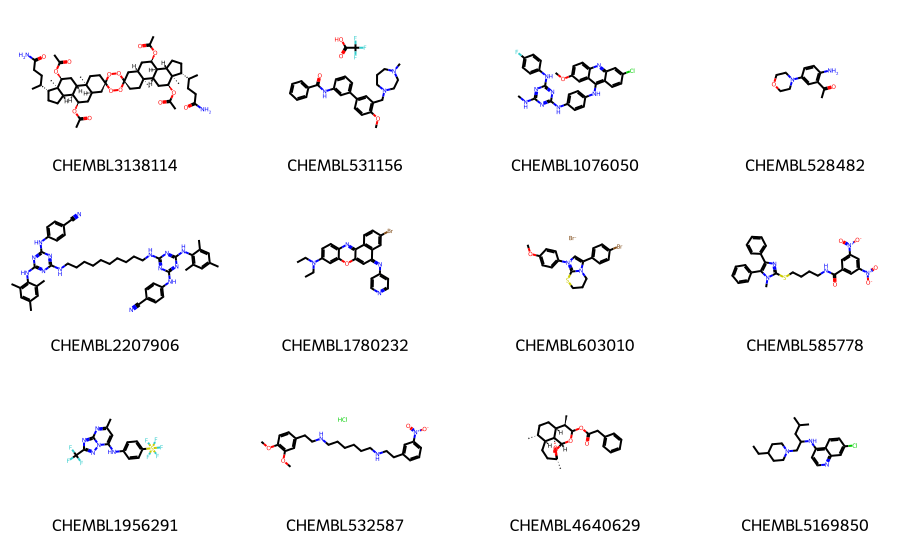

In [6]:
amostra = moleculas.head(12)

Draw.MolsToGridImage(
    list(amostra["mol"]),
    legends=list(amostra["molecule_chembl_id"]),
    molsPerRow=4,
    subImgSize=(230, 180),
)

## 3. Descritores fisico-quimicos

Um descritor e um numero calculado a partir da estrutura que resume alguma
propriedade da molecula inteira: massa, lipofilicidade, area polar, contagem de
grupos funcionais.

O RDKit traz mais de 200 descritores. Aqui usamos seis, escolhidos por serem
interpretaveis e por aparecerem na **regra dos cinco de Lipinski**, uma
heuristica classica de permeabilidade oral.


In [7]:
DESCRITORES = {
    "MolWt": Descriptors.MolWt,                      # massa molecular
    "MolLogP": Descriptors.MolLogP,                  # lipofilicidade estimada
    "TPSA": Descriptors.TPSA,                        # area de superficie polar
    "NumHDonors": Descriptors.NumHDonors,            # doadores de ligacao de H
    "NumHAcceptors": Descriptors.NumHAcceptors,      # aceptores de ligacao de H
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
}

tabela = pd.DataFrame(
    {nome: moleculas["mol"].map(funcao) for nome, funcao in DESCRITORES.items()}
)
tabela.insert(0, "molecule_chembl_id", moleculas["molecule_chembl_id"])

tabela.head()

,molecule_chembl_id,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds
0,CHEMBL3138114,1011.304,8.57640,228.30,2,14,12
1,CHEMBL531156,543.586,5.38530,82.11,2,5,6
2,CHEMBL1076050,567.028,7.64660,108.91,4,9,8
3,CHEMBL528482,220.272,1.30800,55.56,1,4,2
4,CHEMBL2207906,829.074,11.26968,197.10,6,14,21


In [8]:
# Regra dos cinco de Lipinski: MolWt <= 500, LogP <= 5, doadores <= 5,
# aceptores <= 10. Violar uma nao condena a molecula; violar varias e um alerta.
violacoes = (
    (tabela["MolWt"] > 500).astype(int)
    + (tabela["MolLogP"] > 5).astype(int)
    + (tabela["NumHDonors"] > 5).astype(int)
    + (tabela["NumHAcceptors"] > 10).astype(int)
)

print("Violacoes de Lipinski no conjunto:")
print(violacoes.value_counts().sort_index().to_string())
print(f"\nDentro da regra (0 violacoes): {(violacoes == 0).sum()} de {len(tabela)}")

Violacoes de Lipinski no conjunto:
0    16
1     7
2     4
3     2
4     1

Dentro da regra (0 violacoes): 16 de 30


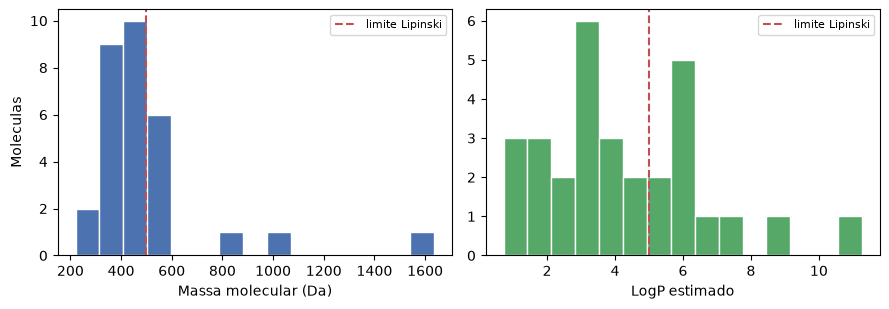

In [9]:
# Distribuicao dos dois descritores mais usados em triagem.
figura, eixos = plt.subplots(1, 2, figsize=(9, 3.2))

eixos[0].hist(tabela["MolWt"], bins=15, color="#4C72B0", edgecolor="white")
eixos[0].axvline(500, color="#C44E52", linestyle="--", label="limite Lipinski")
eixos[0].set_xlabel("Massa molecular (Da)")
eixos[0].set_ylabel("Moleculas")
eixos[0].legend(fontsize=8)

eixos[1].hist(tabela["MolLogP"], bins=15, color="#55A868", edgecolor="white")
eixos[1].axvline(5, color="#C44E52", linestyle="--", label="limite Lipinski")
eixos[1].set_xlabel("LogP estimado")
eixos[1].legend(fontsize=8)

figura.tight_layout()
plt.show()

> **Lição da secao 3.** Descritores sao poucos, interpretaveis e diretamente
> ligados a conceitos quimicos — voce consegue explicar a um quimico o que
> significa "LogP alto". Guarde esse contraste: as proximas duas secoes
> apresentam representacoes com milhares de dimensoes e quase nenhuma leitura
> direta. A escolha entre as duas familias e uma decisao de projeto, e o
> Tutorial 3 volta a ela quando for interpretar o modelo com SHAP.


## 4. MACCS keys

Um *fingerprint* e um vetor binario: cada posicao responde "esta subestrutura
existe nesta molecula?" com 1 ou 0.

As **MACCS keys** sao o caso mais simples de entender porque o significado de
cada posicao e **fixo e conhecido**. Cada bit corresponde a um padrao estrutural
pre-definido, escrito em SMARTS.

Detalhe de implementacao que confunde: a literatura fala em **166 chaves**, mas
o RDKit devolve um vetor de **167 bits** — o indice 0 existe e nunca e usado, de
modo que o bit `i` corresponde a chave `i` da tabela original.


In [10]:
exemplo = moleculas.loc[0]
mol_exemplo = exemplo["mol"]

maccs = MACCSkeys.GenMACCSKeys(mol_exemplo)
bits_ligados = list(maccs.GetOnBits())

print("molecula:", exemplo["molecule_chembl_id"])
print("tamanho do vetor:", maccs.GetNumBits())
print("bits ligados:", len(bits_ligados))
print("indices:", bits_ligados[:15], "...")

molecula: CHEMBL3138114
tamanho do vetor: 167
bits ligados: 55
indices: [57, 66, 72, 84, 89, 90, 92, 96, 98, 101, 102, 104, 105, 108, 110] ...


In [11]:
# O que cada bit ligado significa: MACCSkeys.smartsPatts mapeia indice -> SMARTS.
print(f"{'bit':>5}  SMARTS do padrao estrutural")
print("-" * 62)
for bit in bits_ligados[:8]:
    padrao, _ = MACCSkeys.smartsPatts.get(bit, ("(nao documentado)", 0))
    if len(padrao) > 52:
        padrao = padrao[:49] + "..."
    print(f"{bit:>5}  {padrao}")

  bit  SMARTS do padrao estrutural
--------------------------------------------------------------
   57  [#8R]
   66  [#6]~[#6](~[#6])(~[#6])~*
   72  [#8]~*~*~[#8]
   84  [NH2]
   89  [#8]~*~*~*~[#8]
   90  [$([!#6;!#1;!H0]~*~*~[CH2]~*),$([!#6;!#1;!H0;R]1@...
   92  [#8]~[#6](~[#7])~[#6]
   96  *1~*~*~*~*~1


Cada linha acima e uma pergunta objetiva sobre a estrutura. Essa transparencia e
a grande vantagem das MACCS keys — e tambem sua limitacao: com apenas 166
perguntas fixas, elas nao distinguem moleculas que compartilham os mesmos grupos
funcionais mas os organizam de formas diferentes.


## 5. Morgan fingerprints (ECFP)

Os fingerprints **circulares de Morgan** (tambem chamados ECFP) resolvem a
limitacao anterior de um jeito diferente: em vez de uma lista fixa de perguntas,
eles enumeram os **ambientes atomicos** que de fato existem na molecula.

O algoritmo, em uma frase: para cada atomo, descreve a vizinhanca ate um certo
**raio** de ligacoes, transforma essa descricao em um numero (*hash*) e liga o
bit correspondente.

Dois parametros controlam tudo:

- **`radius`** — quao longe do atomo central a vizinhanca se estende. Raio 2 e o
  padrao de fato na literatura QSAR (equivale ao ECFP4).
- **`fpSize`** — o tamanho do vetor. Como o numero de ambientes possiveis e
  enorme e o vetor e finito, ambientes diferentes podem cair no mesmo bit. Isso
  se chama **colisao**, e e um compromisso aceito, nao um detalhe irrelevante.

Usamos `radius=2, fpSize=2048`, **a mesma configuracao dos dois projetos de
pesquisa** que originaram estes dados — e a que os Tutoriais 2 e 3 reusam.


In [12]:
gerador = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

morgan = gerador.GetFingerprint(mol_exemplo)

print("tamanho do vetor:", morgan.GetNumBits())
print("bits ligados:", morgan.GetNumOnBits())
print(f"densidade: {morgan.GetNumOnBits() / morgan.GetNumBits():.2%}")

tamanho do vetor: 2048
bits ligados: 60
densidade: 2.93%


In [13]:
# Efeito do raio: vizinhancas maiores geram mais ambientes distintos.
print(f"{'raio':>5}  {'bits ligados':>13}")
print("-" * 21)
for raio in [1, 2, 3, 4]:
    g = AllChem.GetMorganGenerator(radius=raio, fpSize=2048)
    print(f"{raio:>5}  {g.GetFingerprint(mol_exemplo).GetNumOnBits():>13}")

 raio   bits ligados
---------------------
    1             36
    2             60
    3             82
    4            101


In [14]:
# Efeito do tamanho do vetor: quanto menor, mais colisoes. Se reduzir fpSize
# nao reduz proporcionalmente os bits ligados, ambientes distintos estao caindo
# no mesmo bit.
print(f"{'fpSize':>7}  {'bits ligados':>13}")
print("-" * 23)
for tamanho in [128, 256, 512, 1024, 2048]:
    g = AllChem.GetMorganGenerator(radius=2, fpSize=tamanho)
    print(f"{tamanho:>7}  {g.GetFingerprint(mol_exemplo).GetNumOnBits():>13}")

 fpSize   bits ligados
-----------------------
    128             50
    256             55
    512             57
   1024             60
   2048             60


### 5.1. O que um bit representa, na pratica

Ate aqui o bit e uma abstracao. Ele nao precisa ser: o RDKit consegue devolver,
para cada bit ligado, **qual atomo central e qual raio** o originaram. Com isso
da para desenhar a subestrutura exata que acendeu aquele bit.

Este e o momento em que "vetor de 2048 dimensoes" vira quimica visivel.


In [15]:
# AdditionalOutput expoe o mapa bit -> (atomo central, raio).
saida_extra = rdFingerprintGenerator.AdditionalOutput()
saida_extra.AllocateBitInfoMap()
gerador.GetFingerprint(mol_exemplo, additionalOutput=saida_extra)

info_bits = dict(saida_extra.GetBitInfoMap())
alguns = sorted(info_bits)[:5]

print(f"{'bit':>6}  {'(atomo, raio)':<20}")
print("-" * 30)
for bit in alguns:
    print(f"{bit:>6}  {str(info_bits[bit]):<20}")

   bit  (atomo, raio)       
------------------------------
     1  ((46, 0), (63, 0))  
     8  ((45, 1), (62, 1))  
    29  ((48, 2), (65, 2))  
    38  ((21, 1), (22, 1), (57, 1), (58, 1))
    80  ((48, 0), (49, 0), (65, 0), (66, 0))


Subestrutura que liga o bit 29:


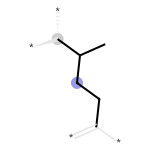

In [16]:
# Desenha a subestrutura responsavel por um bit especifico.
# Escolhemos um bit de raio 2: raio 0 desenharia um atomo solitario, que nao
# ilustra nada. O atomo central sai destacado no desenho.
bit_escolhido = next(
    bit
    for bit, ambientes in sorted(info_bits.items())
    if any(raio >= 2 for _, raio in ambientes)
)
print(f"Subestrutura que liga o bit {bit_escolhido}:")

Draw.DrawMorganBit(mol_exemplo, bit_escolhido, info_bits, useSVG=True)

> **Lição da secao 5.** Morgan fingerprints capturam **presenca de ambientes
> atomicos locais**, nao propriedades globais da molecula. Um modelo treinado
> sobre eles aprende "esta subestrutura aparece em compostos ativos" — o que
> funciona bem dentro de series quimicas conhecidas e mal fora delas. Essa e a
> raiz do problema de generalizacao que o Tutorial 2 vai medir.


## 6. Similaridade de Tanimoto

Com moleculas viradas vetores binarios, "quao parecidas sao duas moleculas?" vira
uma conta. O coeficiente de **Tanimoto** e a medida padrao em quimioinformatica:

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Ou seja: bits ligados em ambas, dividido por bits ligados em pelo menos uma.
Varia de 0 (nenhum bit em comum) a 1 (vetores identicos).

Um valor de Tanimoto acima de ~0,85 com Morgan e frequentemente tratado como
"muito similar", mas esse limiar e convencao, nao lei.


In [17]:
mol_1, mol_2 = moleculas.loc[0, "mol"], moleculas.loc[1, "mol"]

fp_morgan_1, fp_morgan_2 = gerador.GetFingerprint(mol_1), gerador.GetFingerprint(mol_2)
fp_maccs_1, fp_maccs_2 = MACCSkeys.GenMACCSKeys(mol_1), MACCSkeys.GenMACCSKeys(mol_2)

tanimoto_morgan = DataStructs.TanimotoSimilarity(fp_morgan_1, fp_morgan_2)
tanimoto_maccs = DataStructs.TanimotoSimilarity(fp_maccs_1, fp_maccs_2)

print("Mesmo par de moleculas, dois fingerprints:")
print(f"  Tanimoto (Morgan 2048): {tanimoto_morgan:.3f}")
print(f"  Tanimoto (MACCS 167):   {tanimoto_maccs:.3f}")

Mesmo par de moleculas, dois fingerprints:
  Tanimoto (Morgan 2048): 0.071
  Tanimoto (MACCS 167):   0.476


Os dois numeros sao diferentes — e nenhum dos dois esta errado.

MACCS costuma dar valores mais altos porque tem menos bits e pergunta so por
grupos funcionais comuns, que muitas moleculas organicas compartilham. Morgan e
mais exigente porque descreve ambientes especificos.

> **Lição da secao 6.** Similaridade nao e uma propriedade da molecula. E uma
> propriedade do **par (molecula, representacao escolhida)**. Ao reportar
> similaridade em um trabalho, informe sempre o fingerprint e os parametros.


## 7. Matriz de similaridade e series congeneres

Calcular Tanimoto para todos os pares de um conjunto produz uma matriz que pode
ser lida visualmente. E dessa leitura que sai a motivacao para o **scaffold
split** do Tutorial 2.

Para o contraste ficar visivel, vamos montar um conjunto deliberadamente
heterogeneo: duas **series congeneres** (grupos de moleculas que compartilham o
mesmo esqueleto Bemis-Murcko, tipicos de um programa de otimizacao de lead) mais
um bloco de moleculas estruturalmente diversas.

O **esqueleto Bemis-Murcko** e o que sobra da molecula depois de remover as
cadeias laterais: os aneis e o que os conecta. E o criterio que o Tutorial 2 usa
para separar treino e teste.


In [18]:
# Carrega o dataset maior e agrupa por esqueleto Bemis-Murcko.
completo = pd.read_csv(DATA_DIR / "antimalarico_classificacao.csv")


def scaffold_de(smiles):
    """Esqueleto Bemis-Murcko, ignorando estereoquimica.

    Mesma convencao dos projetos de pesquisa: e o criterio que o Tutorial 2 usa
    para separar treino e teste.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(
        MurckoScaffold.GetScaffoldForMol(mol), isomericSmiles=False
    )


amostra_completa = completo.sample(n=1500, random_state=RANDOM_STATE).copy()
amostra_completa["scaffold"] = amostra_completa["rdkit_canonical_smiles"].map(
    scaffold_de
)


def scaffold_substancial(scaffold, min_aneis=3, min_atomos=15):
    """Um scaffold so caracteriza uma serie congenere se for grande o bastante.

    O esqueleto mais frequente de qualquer dataset organico costuma ser o
    benzeno: ele agrupa moleculas que so tem em comum "possuem um anel
    aromatico" — o que nao e uma serie quimica. Exigir varios aneis e um numero
    minimo de atomos filtra esse ruido.
    """
    if not scaffold:
        return False
    mol = Chem.MolFromSmiles(scaffold)
    if mol is None:
        return False
    return (
        rdMolDescriptors.CalcNumRings(mol) >= min_aneis
        and mol.GetNumHeavyAtoms() >= min_atomos
    )


contagem = amostra_completa["scaffold"].value_counts()
maiores_series = contagem[[scaffold_substancial(s) for s in contagem.index]].head(2)

print("Duas maiores series congeneres da amostra:")
for scaffold, n in maiores_series.items():
    print(f"  {n:>3} moleculas | {scaffold}")

Duas maiores series congeneres da amostra:
    9 moleculas | c1ccc(Nc2ccnc3ccccc23)cc1
    8 moleculas | C1CC2CCOC3OC4CCC(C1)C23OO4


As duas series que emergem nao sao arbitrarias — elas correspondem a duas
familias quimicas centrais da quimioterapia antimalarica. Vale desenhar os
esqueletos para ver isso.


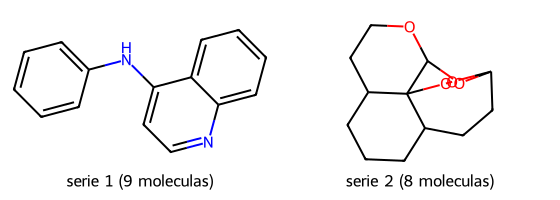

In [19]:
legendas_series = [
    f"serie {i} ({n} moleculas)"
    for i, n in enumerate(maiores_series, start=1)
]

Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in maiores_series.index],
    legends=legendas_series,
    molsPerRow=2,
    subImgSize=(280, 200),
)

A **serie 1** e uma 4-aminoquinolina: o esqueleto da familia da cloroquina. A
**serie 2** traz uma ponte peroxido (a ligacao O-O) em um sistema policiclico —
o motivo estrutural da familia da artemisinina, cuja atividade antimalarica
depende justamente desse peroxido.

Que as duas maiores series de um recorte ChEMBL de *P. falciparum* sejam
exatamente essas duas familias e um bom sinal de que o dataset reflete a
quimica real da area — e tambem um aviso: um modelo treinado aqui vai aprender
muito bem essas duas familias, e pouco sobre qualquer coisa fora delas.


In [20]:
# Monta o conjunto de comparacao: 8 de cada serie + 8 diversas.
blocos, rotulos = [], []

for indice, scaffold in enumerate(maiores_series.index, start=1):
    bloco = amostra_completa[amostra_completa["scaffold"] == scaffold].head(8)
    blocos.append(bloco)
    rotulos += [f"serie {indice}"] * len(bloco)

# As "diversas" precisam excluir os scaffolds das series, senao os blocos
# vazariam um no outro e o contraste do grafico sumiria.
diversas = (
    amostra_completa[~amostra_completa["scaffold"].isin(maiores_series.index)]
    .drop_duplicates(subset="scaffold")
    .head(8)
)
blocos.append(diversas)
rotulos += ["diversas"] * len(diversas)

comparacao = pd.concat(blocos, ignore_index=True)
comparacao["grupo"] = rotulos

fps = [
    gerador.GetFingerprint(Chem.MolFromSmiles(s))
    for s in comparacao["rdkit_canonical_smiles"]
]

# BulkTanimotoSimilarity calcula uma linha inteira de uma vez.
matriz = np.array([DataStructs.BulkTanimotoSimilarity(fp, fps) for fp in fps])

fora_da_diagonal = matriz[~np.eye(len(fps), dtype=bool)]

print("matriz:", matriz.shape)
print(f"similaridade media fora da diagonal: {fora_da_diagonal.mean():.3f}")

matriz: (24, 24)
similaridade media fora da diagonal: 0.144


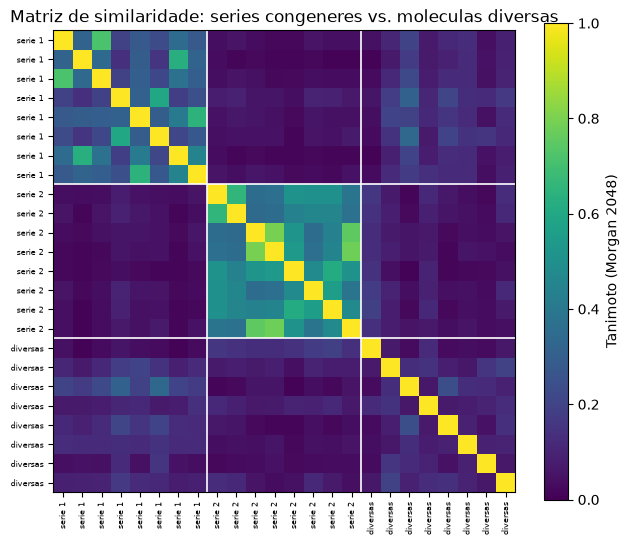

In [21]:
figura, eixo = plt.subplots(figsize=(6.5, 5.5))

imagem = eixo.imshow(matriz, cmap="viridis", vmin=0, vmax=1)
figura.colorbar(imagem, ax=eixo, label="Tanimoto (Morgan 2048)")

# Linhas separando os tres grupos.
limites = np.cumsum(pd.Series(rotulos).value_counts(sort=False).values)[:-1] - 0.5
for limite in limites:
    eixo.axhline(limite, color="white", linewidth=1.2)
    eixo.axvline(limite, color="white", linewidth=1.2)

eixo.set_xticks(range(len(rotulos)))
eixo.set_yticks(range(len(rotulos)))
eixo.set_xticklabels(rotulos, rotation=90, fontsize=6)
eixo.set_yticklabels(rotulos, fontsize=6)
eixo.set_title("Matriz de similaridade: series congeneres vs. moleculas diversas")

figura.tight_layout()
plt.show()

In [22]:
# Quantificando o que o grafico mostra.
grupos = pd.Series(rotulos)
for nome in ["serie 1", "serie 2", "diversas"]:
    indices = np.where(grupos == nome)[0]
    bloco = matriz[np.ix_(indices, indices)]
    fora_diagonal = bloco[~np.eye(len(indices), dtype=bool)]
    print(f"{nome:<10} similaridade media interna: {fora_diagonal.mean():.3f}")

serie 1    similaridade media interna: 0.331
serie 2    similaridade media interna: 0.490
diversas   similaridade media interna: 0.097


Os blocos claros na diagonal sao as series congeneres: moleculas que compartilham
o mesmo esqueleto e diferem por substituintes. O bloco "diversas" e visivelmente
mais escuro.

**E aqui esta a ponte para o Tutorial 2.** Imagine dividir este conjunto em treino
e teste de forma aleatoria. Moleculas da mesma serie cairiam dos dois lados, e o
modelo seria avaliado prevendo compostos quase identicos aos que ja viu. A metrica
resultante mediria memorizacao, nao generalizacao.

O **scaffold split** existe exatamente para impedir isso: ele agrupa por esqueleto
e mantem cada serie inteira de um lado so. O desempenho cai — e a queda e o numero
honesto.

> **Lição da secao 7.** Antes de confiar em qualquer metrica de um modelo QSAR,
> pergunte como o conjunto de teste foi construido.


## 8. Fechamento

O que levar deste tutorial:

- a mesma molecula admite varias representacoes numericas, e a escolha muda o
  resultado do modelo;
- **descritores** sao poucos e interpretaveis; **fingerprints** sao muitos e
  opacos, mas capturam detalhe estrutural que descritores globais perdem;
- fingerprints de Morgan codificam presenca de ambientes atomicos locais, nao
  propriedades globais;
- similaridade estrutural depende do fingerprint escolhido — sempre reporte qual
  foi usado;
- series congeneres inflam metricas quando o split e aleatorio, e essa e a razao
  de existir do scaffold split.

**Proximo:** [Tutorial 2 — QSAR de classificacao](02_qsar_classificacao.ipynb)


---

## Exercicios

Tente resolver antes de abrir a solucao.

### Exercicio 1

A cloroquina tem SMILES `CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12`. Calcule os seis
descritores da secao 3 para ela e diga quantas violacoes de Lipinski ela comete.

<details>
<summary>Solucao</summary>

```python
cloroquina = Chem.MolFromSmiles("CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12")

valores = {nome: funcao(cloroquina) for nome, funcao in DESCRITORES.items()}
for nome, valor in valores.items():
    print(f"{nome:<20} {valor:.2f}")

violacoes_cloroquina = sum([
    valores["MolWt"] > 500,
    valores["MolLogP"] > 5,
    valores["NumHDonors"] > 5,
    valores["NumHAcceptors"] > 10,
])
print("\nviolacoes:", violacoes_cloroquina)
```

A cloroquina fica dentro da regra dos cinco — coerente com ser um farmaco de uso
oral.

</details>

### Exercicio 2

Gere o fingerprint de Morgan da cloroquina com raio 2 e com raio 3, mantendo
`fpSize=2048`. Quantos bits cada um liga? Por que o numero cresce?

<details>
<summary>Solucao</summary>

```python
for raio in [2, 3]:
    g = AllChem.GetMorganGenerator(radius=raio, fpSize=2048)
    print(f"raio {raio}: {g.GetFingerprint(cloroquina).GetNumOnBits()} bits ligados")
```

O numero cresce porque cada atomo passa a gerar um ambiente adicional, maior. O
raio 3 nao substitui o raio 2: os ambientes menores continuam sendo codificados,
e os maiores se somam a eles.

</details>

### Exercicio 3

No conjunto `moleculas`, encontre o par mais similar e o par mais dissimilar
segundo Tanimoto com Morgan. Desenhe os dois pares e compare visualmente.

<details>
<summary>Solucao</summary>

```python
fps_conjunto = [gerador.GetFingerprint(m) for m in moleculas["mol"]]
matriz_conjunto = np.array(
    [DataStructs.BulkTanimotoSimilarity(fp, fps_conjunto) for fp in fps_conjunto]
)

# Ignora a diagonal (similaridade de cada molecula consigo mesma = 1).
np.fill_diagonal(matriz_conjunto, np.nan)

i_max, j_max = np.unravel_index(np.nanargmax(matriz_conjunto), matriz_conjunto.shape)
i_min, j_min = np.unravel_index(np.nanargmin(matriz_conjunto), matriz_conjunto.shape)

print(f"mais similar:   {matriz_conjunto[i_max, j_max]:.3f}")
print(f"mais dissimilar: {matriz_conjunto[i_min, j_min]:.3f}")

Draw.MolsToGridImage(
    [moleculas.loc[i, "mol"] for i in (i_max, j_max, i_min, j_min)],
    legends=["similar A", "similar B", "dissimilar A", "dissimilar B"],
    molsPerRow=4,
    subImgSize=(230, 180),
)
```

Como este conjunto foi montado com scaffolds distintos de proposito, mesmo o par
"mais similar" tem Tanimoto modesto. Compare com as series congeneres da secao 7.

</details>

### Exercicio 4

Os SMILES `C1=CC=CC=C1` e `c1ccccc1` representam o mesmo composto? Justifique com
codigo, sem comparar as strings diretamente.

<details>
<summary>Solucao</summary>

```python
a = Chem.MolToSmiles(Chem.MolFromSmiles("C1=CC=CC=C1"))
b = Chem.MolToSmiles(Chem.MolFromSmiles("c1ccccc1"))

print(a, "|", b, "| iguais:", a == b)
```

Sim, ambos sao benzeno. O primeiro escreve as duplas explicitamente (notacao
Kekule) e o segundo usa a notacao aromatica em minusculas. A canonicalizacao
converge para a mesma string — que e exatamente o motivo de nunca comparar SMILES
brutos.

</details>
